<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.29MB/s    in 31s     

2026-09-30 16:42:09 (4.98 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



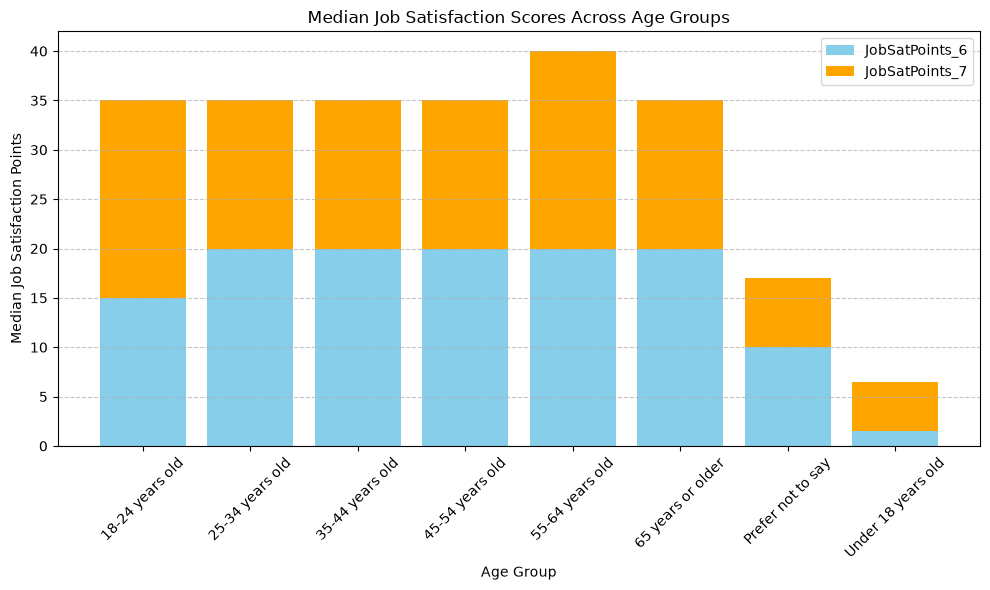

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir variables a numéricas y agrupar por grupo de edad obteniendo la mediana
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7_num'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

df_age_sat = df.groupby('Age')[['JobSatPoints_6_num', 'JobSatPoints_7_num']].median().dropna()

# Crear gráfico de barras apiladas (Stacked Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(df_age_sat.index, df_age_sat['JobSatPoints_6_num'], label='JobSatPoints_6', color='skyblue')
plt.bar(df_age_sat.index, df_age_sat['JobSatPoints_7_num'], bottom=df_age_sat['JobSatPoints_6_num'], label='JobSatPoints_7', color='orange')

plt.title('Median Job Satisfaction Scores Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


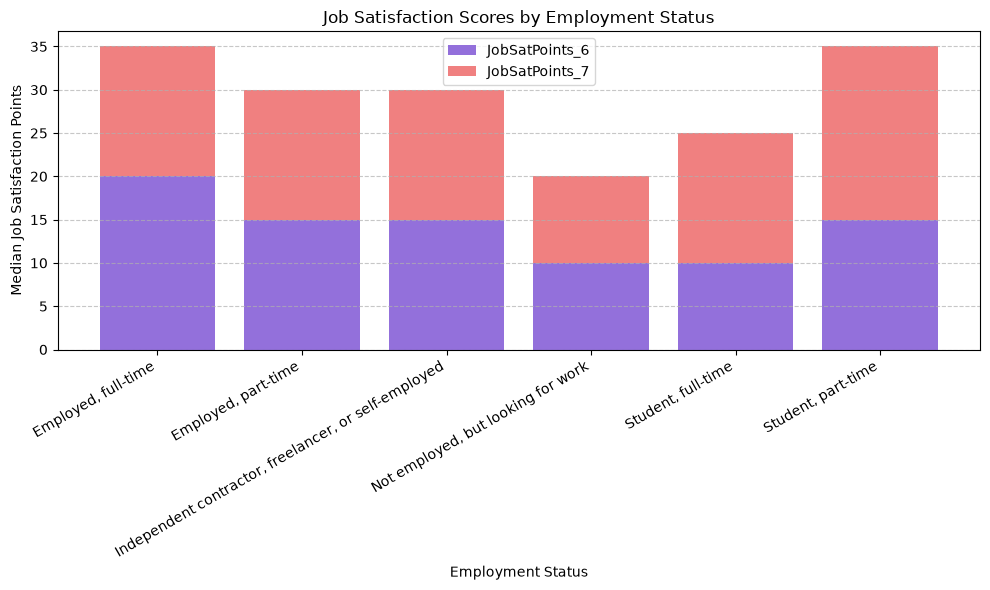

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separar los valores de Employment si están delimitados por ';'
df_emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna().copy()
df_emp['JobSatPoints_6_num'] = pd.to_numeric(df_emp['JobSatPoints_6'], errors='coerce')
df_emp['JobSatPoints_7_num'] = pd.to_numeric(df_emp['JobSatPoints_7'], errors='coerce')

df_emp['Employment_Split'] = df_emp['Employment'].astype(str).str.split(';')
df_exploded = df_emp.explode('Employment_Split')

# 2. Seleccionar solo los 6 tipos de empleo más comunes para evitar saturar el gráfico
top_employment = df_exploded['Employment_Split'].value_counts().head(6).index
df_filtered = df_exploded[df_exploded['Employment_Split'].isin(top_employment)]

# 3. Agrupar obteniendo la mediana
df_emp_sat = df_filtered.groupby('Employment_Split')[['JobSatPoints_6_num', 'JobSatPoints_7_num']].median().dropna()

# 4. Crear el gráfico de barras apiladas
plt.figure(figsize=(10, 6))
plt.bar(df_emp_sat.index, df_emp_sat['JobSatPoints_6_num'], label='JobSatPoints_6', color='mediumpurple')
plt.bar(df_emp_sat.index, df_emp_sat['JobSatPoints_7_num'], bottom=df_emp_sat['JobSatPoints_6_num'], label='JobSatPoints_7', color='lightcoral')

plt.title('Job Satisfaction Scores by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


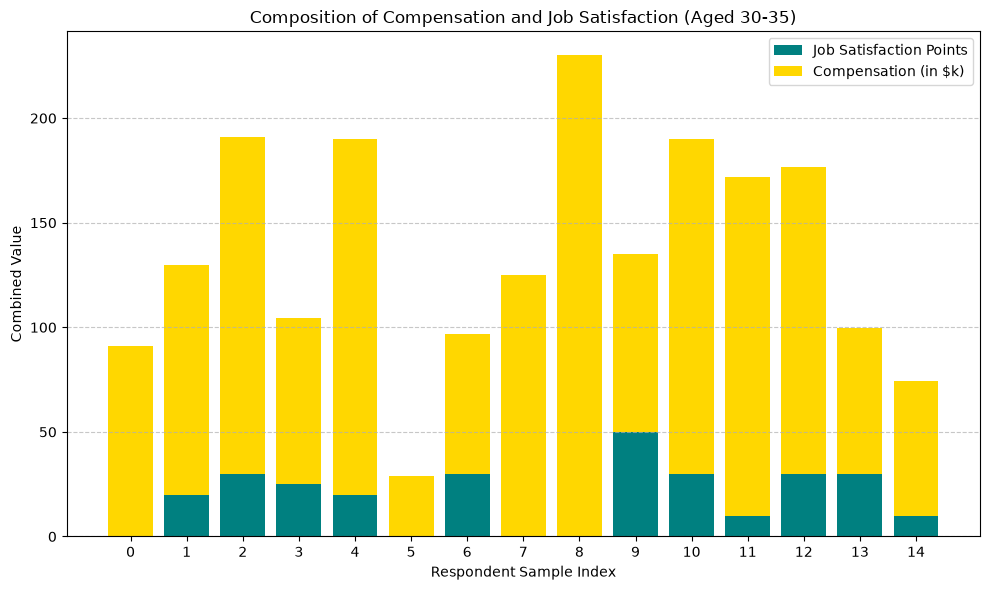

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar encuestados en el rango de edad 30-35 (o '25-34 years' / '35-44 years')
df_30_35 = df[df['Age'].astype(str).str.contains('30|35|25-34|35-44', na=False)].copy()

df_30_35['Comp_k'] = pd.to_numeric(df_30_35['ConvertedCompYearly'], errors='coerce') / 1000
df_30_35['Sat_num'] = pd.to_numeric(df_30_35['JobSatPoints_6'], errors='coerce')

# Tomar una muestra representativa limpia de 15 encuestados para mantener el gráfico legible
df_sample = df_30_35[['Comp_k', 'Sat_num']].dropna().head(15).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.bar(df_sample.index.astype(str), df_sample['Sat_num'], label='Job Satisfaction Points', color='teal')
plt.bar(df_sample.index.astype(str), df_sample['Comp_k'], bottom=df_sample['Sat_num'], label='Compensation (in $k)', color='gold')

plt.title('Composition of Compensation and Job Satisfaction (Aged 30-35)')
plt.xlabel('Respondent Sample Index')
plt.ylabel('Combined Value')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


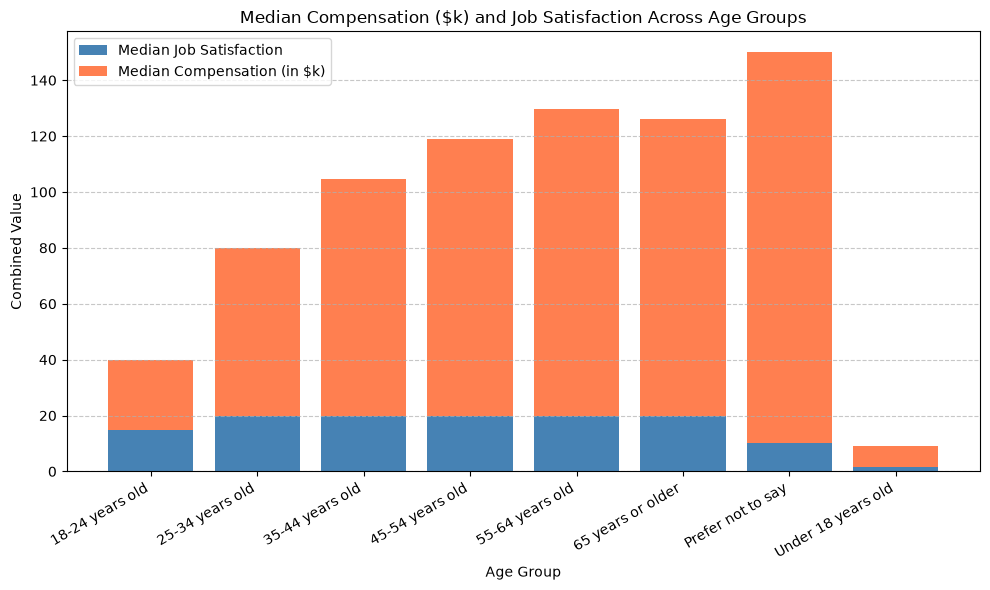

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir variables a numéricas y calcular medianas por grupo de edad
df['Comp_k'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce') / 1000
df['Sat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

df_age_medians = df.groupby('Age')[['Sat_num', 'Comp_k']].median().dropna()

plt.figure(figsize=(10, 6))
plt.bar(df_age_medians.index, df_age_medians['Sat_num'], label='Median Job Satisfaction', color='steelblue')
plt.bar(df_age_medians.index, df_age_medians['Comp_k'], bottom=df_age_medians['Sat_num'], label='Median Compensation (in $k)', color='coral')

plt.title('Median Compensation ($k) and Job Satisfaction Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Combined Value')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


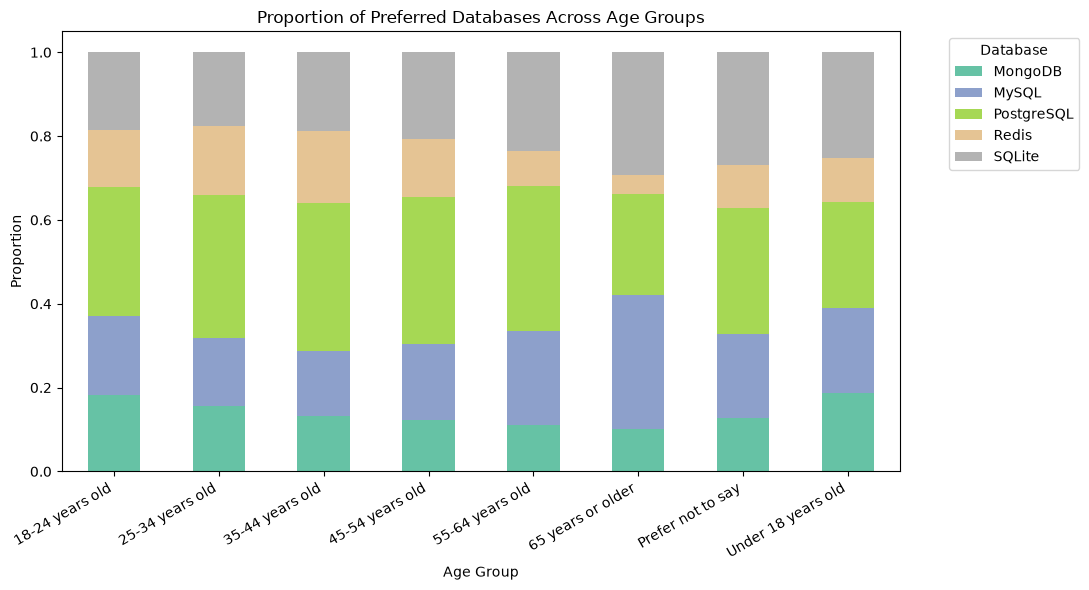

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos y resetear índice para evitar índices duplicados
df_db = df[['Age', 'DatabaseWantToWorkWith']].dropna().copy()
df_db['Database'] = df_db['DatabaseWantToWorkWith'].astype(str).str.split(';')
df_db_exploded = df_db.explode('Database').reset_index(drop=True)

# 2. Filtrar las 5 bases de datos más populares
top5_dbs = df_db_exploded['Database'].value_counts().head(5).index
df_filtered_db = df_db_exploded[df_db_exploded['Database'].isin(top5_dbs)]

# 3. Agrupar y normalizar por grupo de edad
db_counts = df_filtered_db.groupby(['Age', 'Database']).size().unstack(fill_value=0)
db_pivot = db_counts.div(db_counts.sum(axis=1), axis=0)

# 4. Graficar barras apiladas
db_pivot.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='Set2')

plt.title('Proportion of Preferred Databases Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


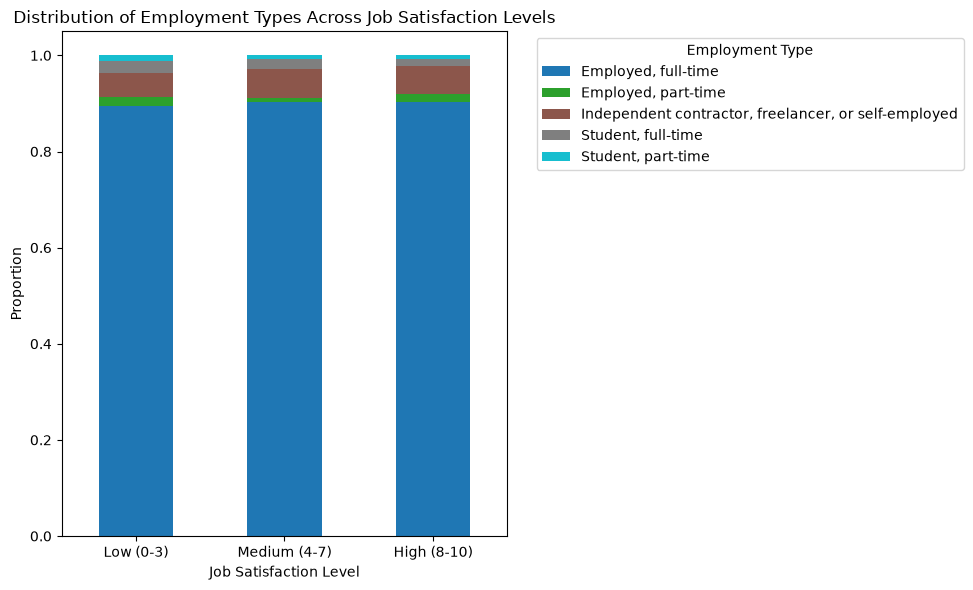

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Limpiar datos y convertir la satisfacción a valor numérico entero
df_emp_sat = df[['JobSatPoints_6', 'Employment']].dropna().copy().reset_index(drop=True)
df_emp_sat['JobSatPoints_6_num'] = pd.to_numeric(df_emp_sat['JobSatPoints_6'], errors='coerce')
df_emp_sat = df_emp_sat.dropna(subset=['JobSatPoints_6_num'])

# 2. Tomar el tipo de empleo principal
df_emp_sat['Employment_Clean'] = df_emp_sat['Employment'].astype(str).str.split(';').str[0]

# 3. Filtrar los 5 tipos de empleo más comunes
top5_emp = df_emp_sat['Employment_Clean'].value_counts().head(5).index
df_filtered_emp = df_emp_sat[df_emp_sat['Employment_Clean'].isin(top5_emp)].copy()

# 4. Agrupar la satisfacción en 3 rangos claros (Bajo, Medio, Alto)
bins = [-1, 3, 7, 10]
labels = ['Low (0-3)', 'Medium (4-7)', 'High (8-10)']
df_filtered_emp['Sat_Level'] = pd.cut(df_filtered_emp['JobSatPoints_6_num'], bins=bins, labels=labels)

# 5. Agrupar y calcular proporciones
emp_counts = df_filtered_emp.groupby(['Sat_Level', 'Employment_Clean'], observed=False).size().unstack(fill_value=0)
emp_pivot = emp_counts.div(emp_counts.sum(axis=1), axis=0)

# 6. Graficar barras apiladas
emp_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')

plt.title('Distribution of Employment Types Across Job Satisfaction Levels')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


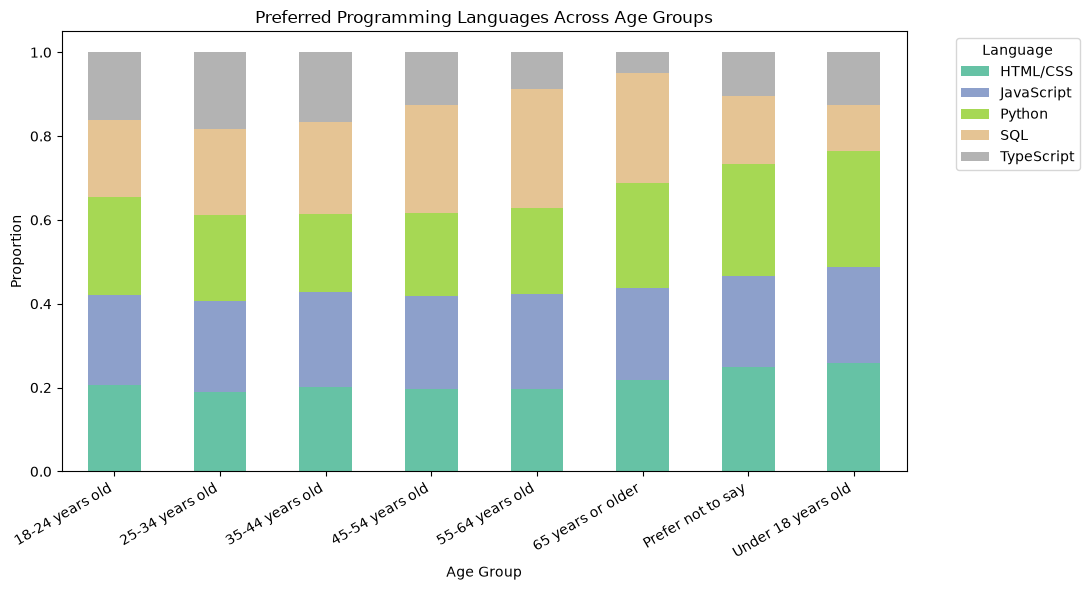

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Verificar la columna de lenguajes admirados y separar valores
lang_col = 'LanguageAdmired' if 'LanguageAdmired' in df.columns else 'LanguageHaveWorkedWith'
df_lang = df[['Age', lang_col]].dropna().copy()
df_lang['Language'] = df_lang[lang_col].astype(str).str.split(';')
df_lang_exploded = df_lang.explode('Language').reset_index(drop=True)

# 2. Seleccionar los 5 lenguajes más populares para mantener el gráfico legible
top5_langs = df_lang_exploded['Language'].value_counts().head(5).index
df_filtered_lang = df_lang_exploded[df_lang_exploded['Language'].isin(top5_langs)]

# 3. Agrupar y calcular proporciones por grupo de edad
lang_counts = df_filtered_lang.groupby(['Age', 'Language']).size().unstack(fill_value=0)
lang_pivot = lang_counts.div(lang_counts.sum(axis=1), axis=0)

# 4. Crear el gráfico de barras apiladas
lang_pivot.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='Set2')

plt.title('Preferred Programming Languages Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


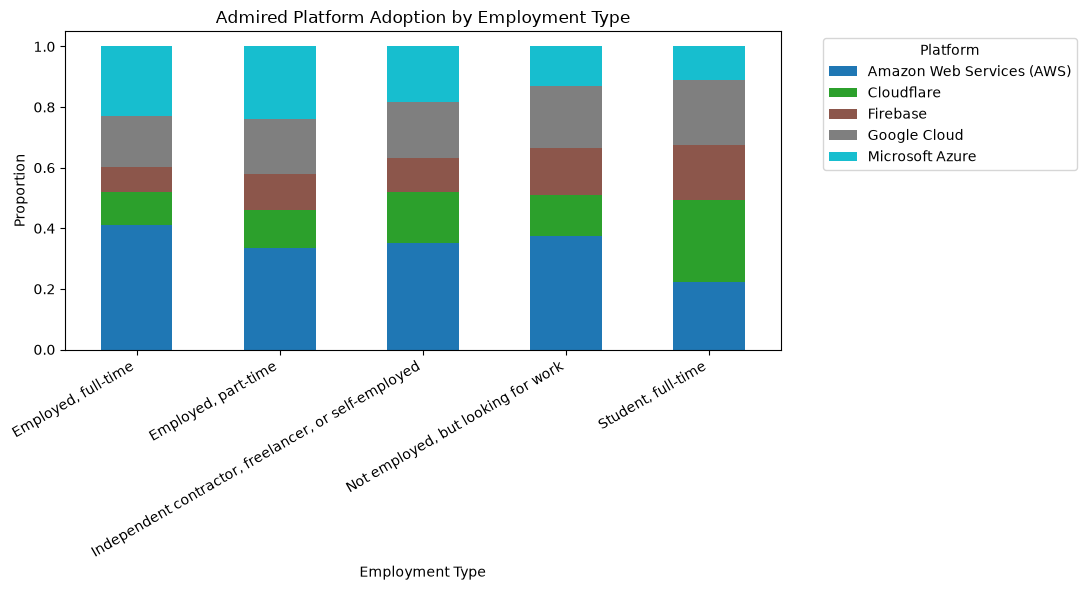

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Verificar columna de plataformas admiradas y tipo de empleo
plat_col = 'PlatformAdmired' if 'PlatformAdmired' in df.columns else 'PlatformHaveWorkedWith'
df_plat = df[['Employment', plat_col]].dropna().copy().reset_index(drop=True)

# Tomar el tipo de empleo principal y separar las plataformas
df_plat['Employment_Clean'] = df_plat['Employment'].astype(str).str.split(';').str[0]
df_plat['Platform'] = df_plat[plat_col].astype(str).str.split(';')
df_plat_exploded = df_plat.explode('Platform').reset_index(drop=True)

# 2. Seleccionar los 5 tipos de empleo y las 5 plataformas más comunes
top5_emp = df_plat_exploded['Employment_Clean'].value_counts().head(5).index
top5_plats = df_plat_exploded['Platform'].value_counts().head(5).index

df_filtered_plat = df_plat_exploded[
    (df_plat_exploded['Employment_Clean'].isin(top5_emp)) & 
    (df_plat_exploded['Platform'].isin(top5_plats))
]

# 3. Agrupar y calcular proporciones
plat_counts = df_filtered_plat.groupby(['Employment_Clean', 'Platform']).size().unstack(fill_value=0)
plat_pivot = plat_counts.div(plat_counts.sum(axis=1), axis=0)

# 4. Crear el gráfico de barras apiladas
plat_pivot.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab10')

plt.title('Admired Platform Adoption by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
